<div style="display: flex; background-color: RGB(255,114,0);" >
<h1 style="margin: auto; padding: 30px; ">ANALYSE DU STOCK ET DES VENTES DU SITE BOTTLENECK</h1>
</div>

# OBJECTIF DE CE NOTEBOOK

Bienvenue dans l'outil plébiscité par les analystes de données Jupyter.

Il s'agit d'un outil permettant de mixer et d'alterner code, texte et graphiques.

Cet outil est formidable pour plusieurs raisons:

+ Il permet de tester des lignes de codes au fur et à mesure de votre rédaction, de constater immédiatement le résultat d'une instruction, de la corriger si nécessaire.
+ Il permet aussi de rédiger du texte pour expliquer l'approche suivie ou les résultats d'une analyse et de le mettre en forme grâce à du code html ou plus simple avec **Markdown**
+ Il est possible d'ajouter des graphiques

Pour vous aider dans vos premiers pas à l'usage de Jupyter et de Python, nous avons rédigé ce notebook en vous indiquant les instructions à suivre.

Il vous suffit pour cela de saisir le code Python répondant à l'instruction donnée.

Vous verrez de temps à autre le code Python répondant à une instruction donnée mais cela est fait pour vous aider à comprendre la nature du travail qui vous est demandé.

Et gardez à l'esprit qu'il n'y a pas de solution unique pour résoudre un problème et qu'il y a autant de résolutions de problèmes que de développeurs ;)...



<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 1 - Importation des librairies et chargement des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.1 - Importation des librairies</h3>
</div>

In [1]:
#Importation de la librairie Pandas
import pandas as pd

In [2]:
#Importation de la librairie plotly express
import plotly.express as px

In [3]:
#Trouver dans Google l'instruction permettant d'afficher toutes les colonnes d'un dataframe
#Saisir dans Google les mots clés "display all columns dataframe Pandas" par exemple.
#Dans les résultats de la recherche, privilégier les solutions provenant de Stack Overflow ou Medium
pd.set_option('display.max_columns', None)

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.2 - Chargements des fichiers</h3>
</div>

In [4]:
#Importation du fichier web.xlsx
df_web = pd.read_excel("web.xlsx")
#Importation du fichier erp.xlsx
df_erp = pd.read_excel("erp.xlsx")
#Importation du fichier liaison.xlsx
df_liaison = pd.read_excel("liaison.xlsx")


c:\Users\Utilisateur\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
c:\Users\Utilisateur\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
c:\Users\Utilisateur\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 2 - Analyse exploratoire des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1 - Analyse exploratoire du fichier erp.xlsx</h3>
</div>

In [5]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(df_erp.shape[0]))
print("Le tableau comporte {} colonne(s)".format(df_erp.shape[1]))

df_erp.shape[0]

Le tableau comporte 825 observation(s) ou article(s)
Le tableau comporte 6 colonne(s)


825

In [6]:
df_erp.shape[1]

6

In [7]:
#Consulter le nombre de colonnes
#La nature des données dans chacune des colonnes
#Le nombre de valeurs présentes dans chacune des colonnes
df_erp.info()


<class 'pandas.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_id      825 non-null    int64  
 1   onsale_web      825 non-null    int64  
 2   price           825 non-null    float64
 3   stock_quantity  825 non-null    int64  
 4   stock_status    825 non-null    str    
 5   purchase_price  825 non-null    float64
dtypes: float64(2), int64(3), str(1)
memory usage: 38.8 KB


In [8]:
#Afficher les 5 premières lignes de la table
df_erp.head(5)

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
0,3847,1,24.2,16,instock,12.88
1,3849,1,34.3,10,instock,17.54
2,3850,1,20.8,0,outofstock,10.64
3,4032,1,14.1,26,instock,6.92
4,4039,1,46.0,3,outofstock,23.77


In [9]:
#Vérifier si il y a des lignes en doublon dans la colonne product_id
df_erp.duplicated(subset=['product_id']).sum()

np.int64(0)

In [10]:
df_erp['stock_status'].value_counts()

stock_status
instock       733
outofstock     92
Name: count, dtype: int64

In [11]:
#Afficher les valeurs distinctes de la colonne stock_status
#À quelle(s) autre(s) colonne(s) sont-elles liées ?
df_erp[['stock_status','stock_quantity']]#les deux colonnes sont liées, car le stock_quantity est la quantité de stock disponible pour chaque statut de stock.

,stock_status,stock_quantity
0,instock,16
1,instock,10
2,outofstock,0
3,instock,26
4,outofstock,3
...,...,...
820,instock,30
821,instock,9
822,instock,6
823,instock,14


In [12]:
#Création d'une colonne "stock_status_2"
#La valeur de cette deuxième colonne sera fonction de la valeur dans la colonne "stock_quantity"
#Si la valeur de la colonne "stock_quantity" est nulle, renseigner "outofstock" sinon mettre "instock"
import numpy as np
df_erp['stock_status_2'] = np.where(df_erp['stock_quantity'] <= 0, 'outofstock', 'instock')

In [13]:
#Vérifions que les 2 colonnes sont identiques:
#Les 2 colonnes sont strictement identiques si les valeurs de chaque ligne sont strictement identiques 2 à 2
#La comparaison de 2 colonnes peut se réaliser simplement avec l'instruction ci-dessous:
df_erp["stock_status"] == df_erp["stock_status_2"]

#Le résultat est l'affichage de True ou False pour chacune des lignes du dataset
#C'est un bon début, mais difficile à exploiter

0       True
1       True
2       True
3       True
4      False
       ...  
820     True
821     True
822     True
823     True
824     True
Length: 825, dtype: bool

In [14]:
df_erp.head(30)

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
0,3847,1,24.2,16,instock,12.88,instock
1,3849,1,34.3,10,instock,17.54,instock
2,3850,1,20.8,0,outofstock,10.64,outofstock
3,4032,1,14.1,26,instock,6.92,instock
4,4039,1,46.0,3,outofstock,23.77,instock
5,4040,1,34.3,12,instock,18.25,instock
6,4041,1,32.7,12,instock,17.57,instock
7,4042,1,31.2,15,instock,15.48,instock
8,4043,1,60.0,0,outofstock,29.45,outofstock
9,4045,1,42.6,5,instock,22.01,instock


In [15]:
#Mais il est possible de synthétiser ce résultat en effectuant la somme de cette colonne:
#True vaut 1 et False 0
#Nous devrions obtenir la somme de 824 qui correspond au nombre de lignes dans ce dataset



In [16]:
#Si les colonnes ne sont absolument pas identiques ligne à ligne alors identifier la ligne en écart
##Dans ce cas je vous donne ce lien pour apprendre à réaliser des filtres dans Pandas:
##https://bitbucket.org/hrojas/learn-pandas/src/master/
##Lesson 3
df_erp[ df_erp["stock_status"] != df_erp["stock_status_2"] ]


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
4,4039,1,46.0,3,outofstock,23.77,instock
398,4885,1,18.7,0,instock,9.66,outofstock


In [17]:
#Corriger la ou les données incohérentes

#Vérification en utilisant le même code que plus haut pour afficher les problèmes
df_erp.loc[ df_erp["stock_quantity"] <= 0, "stock_status" ] = "outofstock"
df_erp[ df_erp["stock_status"] != df_erp["stock_status_2"] ]
df_erp.loc[ df_erp["stock_quantity"] > 0, "stock_status" ] = "instock"


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1 - Analyse exploratoire de chaque variable du fichier erp.xlsx</h3>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.1 - Analyse de la variable PRIX</h3>
</div>

In [18]:
df_erp['price'].min()

np.float64(-20.0)

In [19]:
###############
## LES PRIX  ##
###############

#Vérification des prix: Y a t-il des prix non renseignés, négatifs ou nuls?
#Afficher le ou les prix non renseignés dans la colonne "price"
#Afficher le prix minimum de la colonne "price"
#Afficher le prix maximum de la colonne "price"
df_erp['price'].max()
#Afficher les prix inférieurs à 0 (qu'est-ce qu'il faut en faire ?)
df_erp[ df_erp["price"] < 0 ] 
df_erp.loc[ df_erp["price"] < 0, "price" ] = df_erp["price"].abs()

In [20]:
# faire la corractiobne en dessous 
#. loc faire en sorte de remetrre les prix en positif
#df_erp.loc[ df_erp["price"] < 0, "price" ] = df_erp["price"].abs()

In [21]:
df_erp[df_erp['product_id'].isin([4233, 5017, 6594])]# les articles 4233, 5017 et 6594 avait des prix negatifs ont les a corigeer avec le code ci-dessus


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
151,4233,0,20.0,0,outofstock,10.33,outofstock
469,5017,0,8.0,0,outofstock,4.34,outofstock
739,6594,0,9.1,19,instock,4.61,instock


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.2 - Analyse de la variable STOCK</h3>
</div>

In [22]:
df_erp

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
0,3847,1,24.2,16,instock,12.88,instock
1,3849,1,34.3,10,instock,17.54,instock
2,3850,1,20.8,0,outofstock,10.64,outofstock
3,4032,1,14.1,26,instock,6.92,instock
4,4039,1,46.0,3,instock,23.77,instock
...,...,...,...,...,...,...,...
820,7203,0,45.0,30,instock,23.48,instock
821,7204,0,45.0,9,instock,24.18,instock
822,7247,1,54.8,6,instock,27.18,instock
823,7329,0,26.5,14,instock,13.42,instock


In [23]:
#######################
### stock_quantity  ###
#######################

#Vérification de la colonne stock quantity
#Afficher la quantité minimum de la colonne "stock_quantity"
print(df_erp['stock_quantity'].min())
#Afficher la quantité maximum de la colonne "stock_quantity"
print(df_erp['stock_quantity'].max())

#Afficher les stocks inférieurs à 0 (qu'est-ce qu'il faut en faire ?)
df_erp[ df_erp["stock_quantity"] < 0 ]
#il faut les remplacer par 0 car il n'est pas possible d'avoir un stock négatif. Il s'agit d'une erreur de saisie.

-10
145


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
449,4973,0,10.0,-10,outofstock,4.96,outofstock
573,5700,1,44.5,-1,outofstock,22.30,outofstock


In [24]:
df_erp.loc[ df_erp["stock_quantity"] < 0, "stock_quantity" ] = 0 #remplace les valeurs négatives de la colonne "stock_quantity" par 0
df_erp[ df_erp["stock_quantity"] < 0 ]

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.3 - Analyse de la variable ONSALE_WEB</h3>
</div>

In [25]:
#Vérification de la colonne onsale_web et des valeurs qu'elle contient. Que signifient-elles?
df_erp['onsale_web'].value_counts()

onsale_web
1    716
0    109
Name: count, dtype: int64

In [26]:
#Quelles sont les colonnes à conserver selon vous?
#tous les colonnes sauf celles qui sont redondantes ou inutiles pour l'analyse, comme "stock_status_2" qui a été supprimé


In [27]:
#Supprimer la colonne comportant le libellé "stock_status_2" car elle est redondante 
#avec la colonne "stock_status".
df_erp.drop(columns=['stock_status_2'], inplace=True)

In [28]:
df_erp.columns # Afficher les noms des colonnes

Index(['product_id', 'onsale_web', 'price', 'stock_quantity', 'stock_status',
       'purchase_price'],
      dtype='str')

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.4 - Analyse de la variable prix d'achat</h3>
</div>

In [29]:
######################
##   prix d'achat   ##
######################
#Vérification de la colonne purchase_price : 
#Afficher le ou les prix non renseignés dans la colonne "purchase_price"
print(df_erp['purchase_price'].isnull().sum()) # Afficher le nombre de prix non renseignés dans la colonne "purchase_price"

#Afficher le prix minimum de la colonne "purchase_price"
print(df_erp['purchase_price'].min()) # Afficher le prix minimum de la colonne "purchase_price"

#Afficher le prix maximum de la colonne "purchase_price"
print(df_erp['purchase_price'].max())   # Afficher le prix maximum de la colonne "purchase_price"

0
2.74
137.81


In [30]:
#Afficher le ou les prix non renseignés dans la colonne "purchase_price"
df_erp['purchase_price'].isnull().sum() # Afficher le nombre de prix non renseignés dans la colonne "purchase_price"

np.int64(0)

In [31]:
df_erp['purchase_price'].min() # Afficher le prix minimum de la colonne "purchase_price"


np.float64(2.74)

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.2 - Analyse exploratoire du fichier web.xlsx</h3>
</div>
 

In [32]:
#Dimension du dataset
#Nombre d'observations
df_web.shape[0]


1513

In [33]:
#Nombre de caractéristiques
df_web.shape[1]

29

In [34]:
#Consulter le nombre de colonnes
df_web.info()
#La nature des données dans chacune des colonnes
df_web.info()


<class 'pandas.DataFrame'>
RangeIndex: 1513 entries, 0 to 1512
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   sku                    1428 non-null   object        
 1   virtual                1513 non-null   int64         
 2   downloadable           1513 non-null   int64         
 3   rating_count           1513 non-null   int64         
 4   average_rating         1430 non-null   float64       
 5   total_sales            1430 non-null   float64       
 6   tax_status             716 non-null    str           
 7   tax_class              0 non-null      float64       
 8   post_author            1430 non-null   float64       
 9   post_date              1430 non-null   datetime64[us]
 10  post_date_gmt          1430 non-null   datetime64[us]
 11  post_content           0 non-null      float64       
 12  product_type           1429 non-null   str           
 13  post_title    

In [35]:
#Le nombre de valeurs présentes dans chacune des colonnes
df_web.count()

sku                      1428
virtual                  1513
downloadable             1513
rating_count             1513
average_rating           1430
total_sales              1430
tax_status                716
tax_class                   0
post_author              1430
post_date                1430
post_date_gmt            1430
post_content                0
product_type             1429
post_title               1430
post_excerpt              716
post_status              1430
comment_status           1430
ping_status              1430
post_password               0
post_name                1430
post_modified            1430
post_modified_gmt        1430
post_content_filtered       0
post_parent              1430
guid                     1430
menu_order               1430
post_type                1430
post_mime_type            714
comment_count            1430
dtype: int64

In [36]:
#Selon vous, quelles sont les colonnes à conserver ?
df_web[['sku','total_sales','product_type','post_type','tax_status']]

,sku,total_sales,product_type,post_type,tax_status
0,11862,3.0,Vin,attachment,NaN
1,16057,5.0,Vin,attachment,NaN
2,14692,5.0,Vin,product,taxable
3,16295,14.0,Vin,attachment,NaN
4,15328,2.0,Vin,product,taxable
...,...,...,...,...,...
1508,16326,5.0,Vin,product,taxable
1509,15662,15.0,Vin,product,taxable
1510,15329,3.0,Vin,attachment,NaN
1511,14827,7.0,Vin,attachment,NaN


In [37]:
#Si vous avez défini des colonnes à supprimer, effectuer l'opération
df_web = df_web[['sku','total_sales','product_type','post_type','tax_status']]


In [38]:
df_web.info()

<class 'pandas.DataFrame'>
RangeIndex: 1513 entries, 0 to 1512
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sku           1428 non-null   object 
 1   total_sales   1430 non-null   float64
 2   product_type  1429 non-null   str    
 3   post_type     1430 non-null   str    
 4   tax_status    716 non-null    str    
dtypes: float64(1), object(1), str(3)
memory usage: 59.2+ KB


In [39]:
#Visualisation des valeurs de la colonne sku
#Quelles sont les valeurs qui ne semblent pas respecter la régle de codification?
df_web['sku'].value_counts()

sku
11862    2
16057    2
14692    2
16295    2
15328    2
        ..
16043    2
15845    2
15951    2
13074    2
14569    2
Name: count, Length: 714, dtype: int64

In [40]:
#Si vous avez identifié des codes articles ne respectant pas la régle de codification, consultez-les


In [41]:
pip install missingno

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [42]:
import missingno as msno

<Axes: >

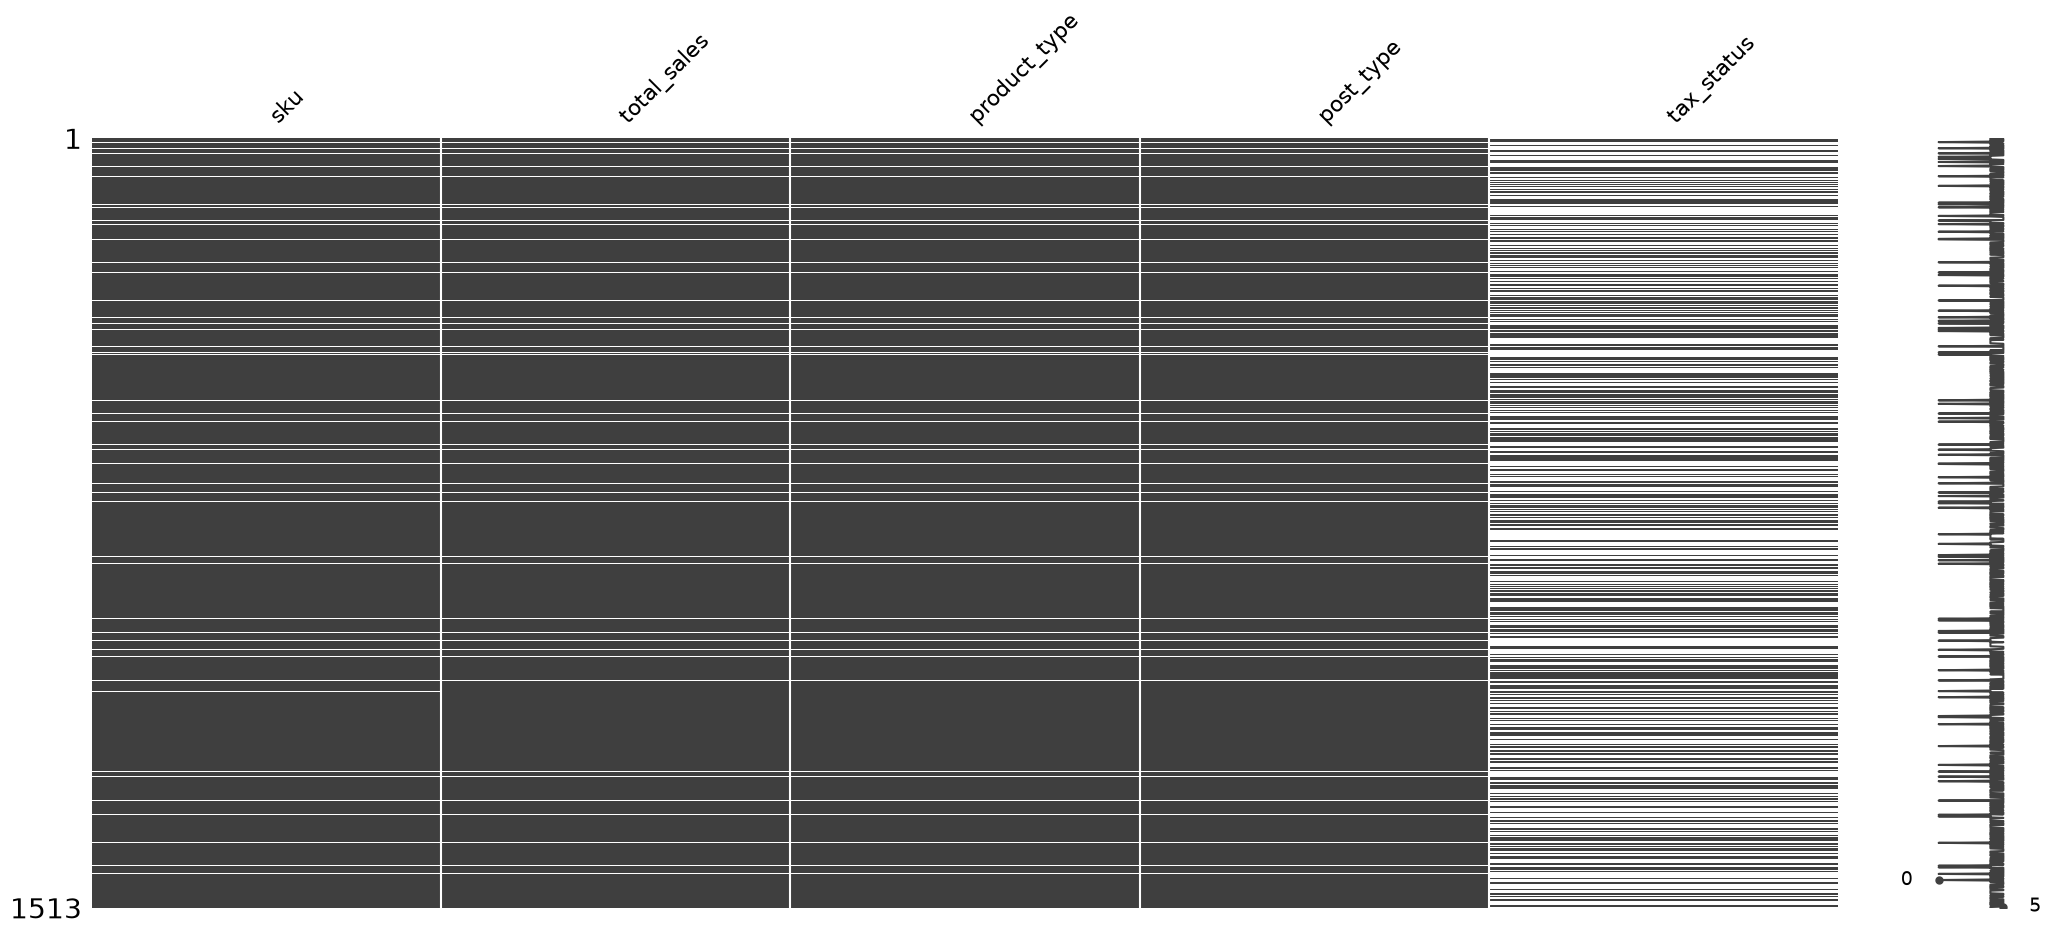

In [43]:
msno.matrix(df_web)

In [44]:
#Identifier les lignes sans code article
df_web.dropna(subset=['sku'], inplace=True) #Supprimer les lignes sans code article ou sku et bie NAN
df_web[df_web['sku'].isnull()]

,sku,total_sales,product_type,post_type,tax_status


<Axes: >

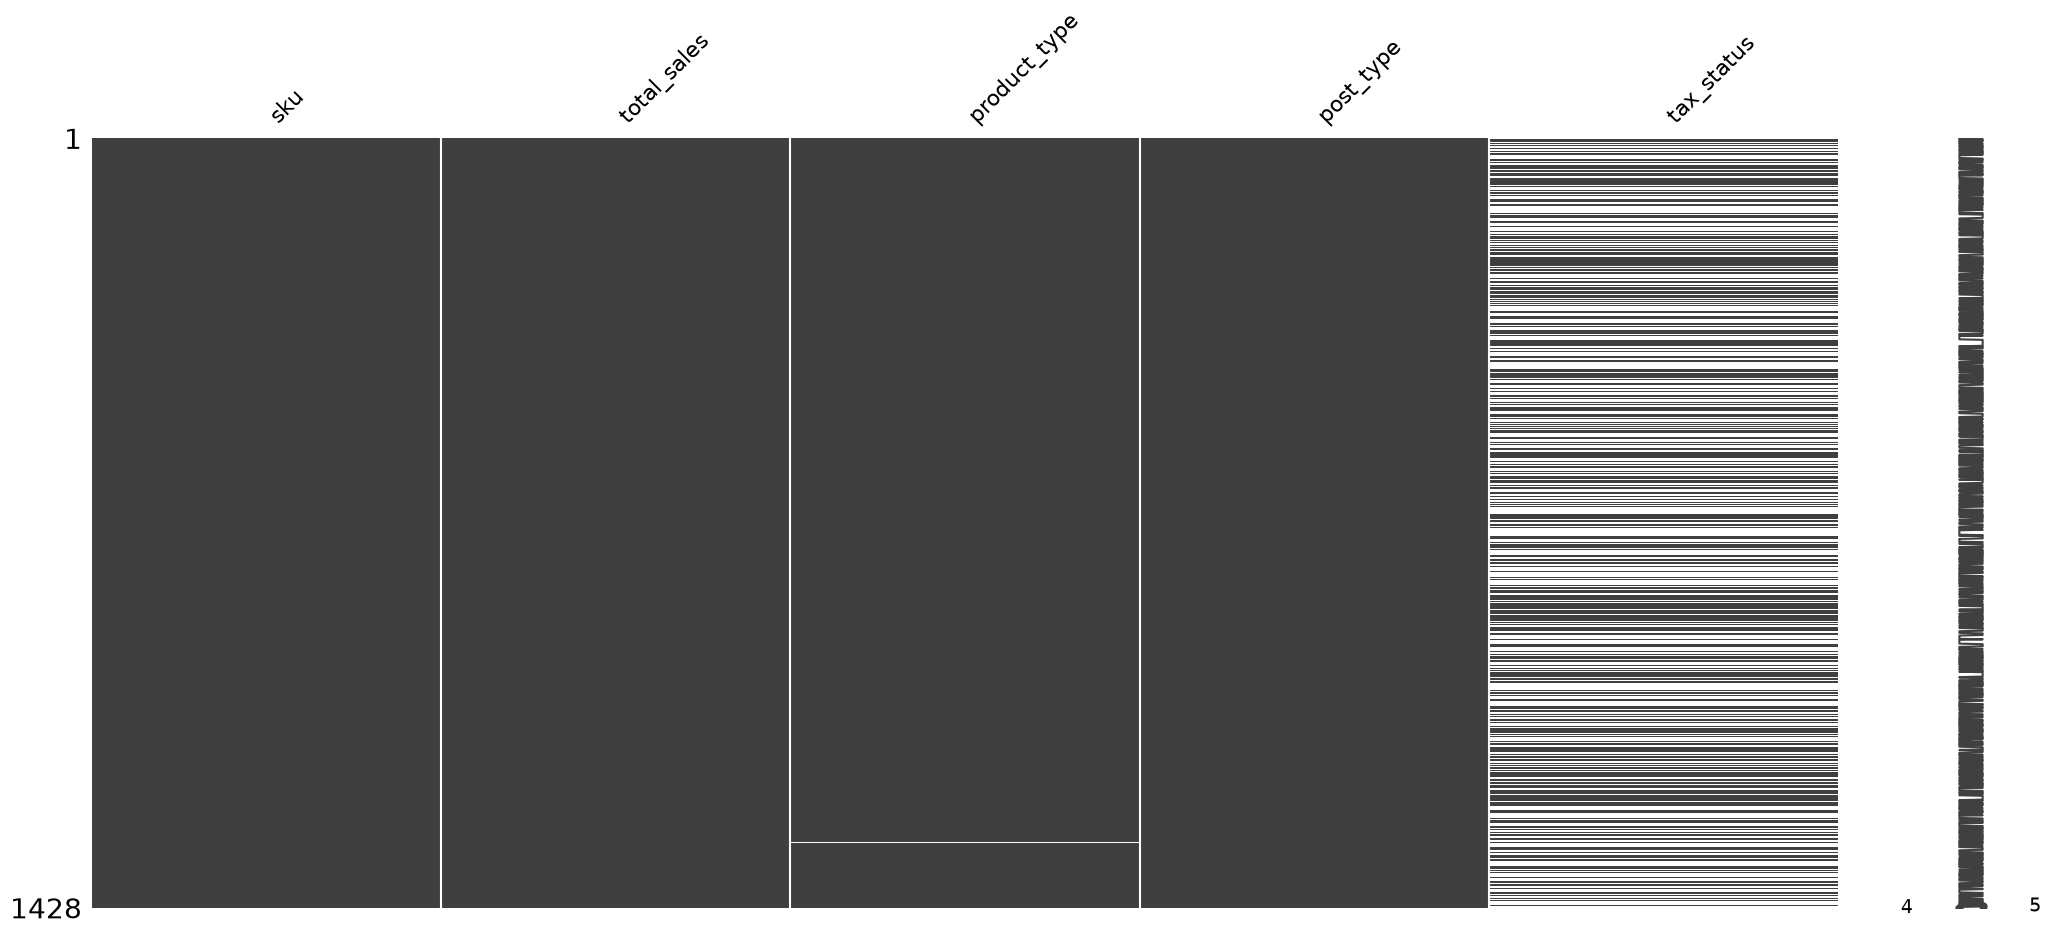

In [45]:
msno.matrix(df_web)

In [46]:
df_web.info()

<class 'pandas.DataFrame'>
Index: 1428 entries, 0 to 1512
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sku           1428 non-null   object 
 1   total_sales   1428 non-null   float64
 2   product_type  1427 non-null   str    
 3   post_type     1428 non-null   str    
 4   tax_status    714 non-null    str    
dtypes: float64(1), object(1), str(3)
memory usage: 66.9+ KB


In [47]:
df_web.head(10)

,sku,total_sales,product_type,post_type,tax_status
0,11862,3.0,Vin,attachment,NaN
1,16057,5.0,Vin,attachment,NaN
2,14692,5.0,Vin,product,taxable
3,16295,14.0,Vin,attachment,NaN
4,15328,2.0,Vin,product,taxable
5,15471,4.0,Vin,attachment,NaN
6,16515,10.0,Vin,product,taxable
7,16246,10.0,Vin,attachment,NaN
9,13572,17.0,Vin,attachment,NaN
10,16513,13.0,Vin,attachment,NaN


In [48]:
df_web[df_web['sku']==11862]

,sku,total_sales,product_type,post_type,tax_status
0,11862,3.0,Vin,attachment,NaN
1001,11862,3.0,Vin,product,taxable


In [49]:
#prendre les lignes que avec  post_type = 'product'
df_web = df_web[df_web['post_type'] == 'product'] 

In [50]:
df_web.info()

<class 'pandas.DataFrame'>
Index: 714 entries, 2 to 1509
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sku           714 non-null    object 
 1   total_sales   714 non-null    float64
 2   product_type  713 non-null    str    
 3   post_type     714 non-null    str    
 4   tax_status    714 non-null    str    
dtypes: float64(1), object(1), str(3)
memory usage: 33.5+ KB


In [51]:
#Pour les codes articles identifiés, réaliser une analyse et définir l'action à entreprendre
# Les lignes sans code article sont toutes vides (NaN partout)


In [52]:
#La clé pour chaque ligne est-elle unique? autrement dit, y a-t-il des doublons?
df_web = df_web[df_web['post_type'] == 'product']
 # Afficher le nombre de doublons dans la colonne "sku"

In [53]:
#df_web['post_type'] == 'product' → regarde chaque ligne et dit True si c'est un produit, False sinon
#df_web[ ... ] → garde seulement les lignes où c'est True
#df_web = → réassigne le résultat dans la même variable
#C'est comme dire : "garde moi seulement les produits".

In [54]:
#Les lignes sans code article semblent être toutes non renseignées
#Pour s'en assurer, réaliser les étapes suivantes:
#1 - Créer un dataframe avec uniquement les lignes sans code article
df_web_sans_sku = df_web[df_web['sku'].isnull()]
#2 - Utiliser la fonction df.info() sur ce nouveau dataframe pour observer le nombre de valeurs renseignées dans chacune des colonnes
df_web_sans_sku.info()
#3 - Que constatez-vous?# on constate que toutes les colonnes sont vides pour les lignes sans code article, ce qui confirme que ces lignes ne contiennent aucune information utile et peuvent être supprimées.

<class 'pandas.DataFrame'>
Index: 0 entries
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sku           0 non-null      object 
 1   total_sales   0 non-null      float64
 2   product_type  0 non-null      str    
 3   post_type     0 non-null      str    
 4   tax_status    0 non-null      str    
dtypes: float64(1), object(1), str(3)
memory usage: 0.0+ bytes


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.3 - Analyse exploratoire du fichier liaison.xlsx</h3>
</div>

In [55]:
#Dimension du dataset
#Nombre d'observations
df_liaison.shape[0]
#Nombre de caractéristiques
df_liaison.shape[1]

2

In [56]:
#Consulter le nombre de colonnes
#La nature des données dans chacune des colonnes
df_liaison.info()
#Le nombre de valeurs présentes dans chacune des colonnes
df_liaison.count()

<class 'pandas.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id_web      734 non-null    object
 1   product_id  825 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 13.0+ KB


id_web        734
product_id    825
dtype: int64

In [57]:
#Les valeurs de la colonne "product_id" sont-elles toutes uniques?
df_liaison.duplicated(subset=['product_id']).sum() # Afficher le nombre de doublons dans la colonne "product_id"

np.int64(0)

In [58]:
#Les valeurs de la colonne "id_web" sont-elles toutes uniques?
df_liaison.duplicated(subset=['id_web']).sum() # Afficher le nombre de doublons dans la colonne "id_web"

np.int64(90)

In [59]:
#Avons-nous des articles sans correspondance?
df_liaison['product_id'].isnull().sum() # Afficher le nombre d'articles sans correspondance dans la colonne "product_id"

np.int64(0)

In [60]:
df_liaison['id_web'].isnull().sum()


np.int64(91)

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 3 - Jonction des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 3.1 - Jonction du fichier df_erp et df_liaison</h3>
</div>

In [61]:
#Fusion des fichiers df_erp et df_liaison
df_erp_liaison = pd.merge(df_erp, df_liaison, on='product_id', how='left')

In [62]:
#Y a t-il des lignes ne "matchant" pas entre les 2 fichiers?
df_erp_liaison[df_erp_liaison['id_web'].isnull()].shape[0]

91

In [63]:
#pd.merge() c'est comme un VLOOKUP dans Excel — ça fusionne deux tableaux en faisant correspondre les lignes par une colonne commune.

#Ici :

#df_erp et df_liaison — les deux tableaux à fusionner
#on='product_id' — la colonne commune qui sert à faire la correspondance
#how='left' — garde toutes les lignes de df_erp, même si elles n'ont pas de correspondance dans df_liaison
#Le résultat df_erp_liaison sera un nouveau tableau avec les colonnes des deux fichiers combinées. 

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 3.2 - Jonction du fichier df_merge et df_web</h3>
</div>

In [64]:
#Fusionner les datasets df_merge et df_web
df_erp_liaison_web = pd.merge(df_erp_liaison, df_web, left_on='id_web', right_on='sku', how='left')


In [65]:
#Avons-nous des lignes sans correspondance?
df_erp_liaison_web[df_erp_liaison_web['sku'].isnull()].shape[0]

111

In [66]:
#df_erp_liaison_web — le nom du nouveau dataframe fusionné
#pd.merge() — la fonction qui fusionne
#df_erp_liaison — le tableau de gauche (base)
#df_web — le tableau de droite (qu'on ajoute)
#left_on='id_web' — la colonne de correspondance dans le tableau de gauche
#right_on='sku' — la colonne de correspondance dans le tableau de droite
#how='left' — garde toutes les lignes du tableau de gauche même sans correspondance

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 4 - Analyse univariée des prix</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.1 - Exploration par la visualisation de données</h3>
</div>

<Axes: title={'center': 'price'}, xlabel='stock_status'>

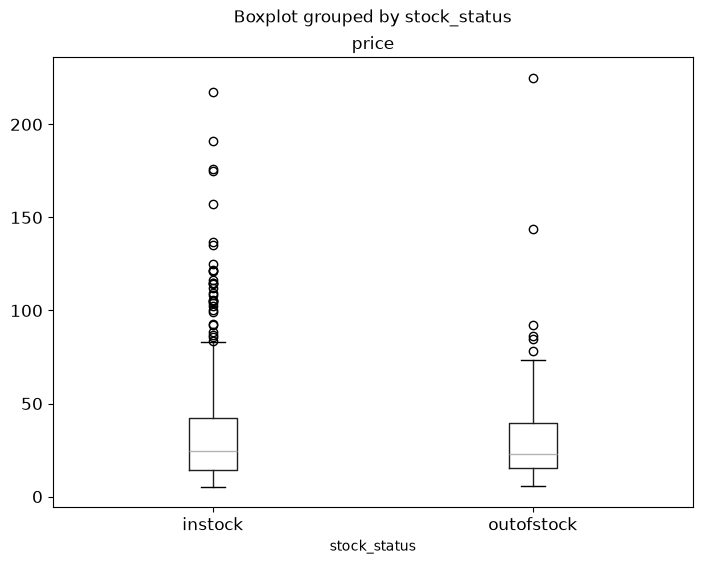

In [67]:
#Création d'une boîte à moustache de la répartition des prix grâce à Pandas
df_erp_liaison_web.boxplot(column='price', by='stock_status', grid=False, showfliers=True, figsize=(8,6), fontsize=12)

In [68]:
df_erp_liaison_web['stock_status'] = df_erp_liaison_web['stock_status'].astype(str)
fig = px.box(df_erp_liaison_web, x='stock_status', y='price', points='all', title='Répartition des prix par statut de stock')
import plotly.io as pio
pio.renderers.default = "browser"
fig.show()


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2 - Exploration par l'utilisation de méthodes statistiques</h3>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2.1 - Identification par le Z-index</h3>
</div>

In [69]:
#Calculer la moyenne du prix
df_erp_liaison_web['price'].mean()  
#Calculer l'écart-type du prix
df_erp_liaison_web['price'].std()
#Calculer le Z-score
df_erp_liaison_web['price_zscore'] = (df_erp_liaison_web['price'] - df_erp_liaison_web['price'].mean()) / df_erp_liaison_web['price'].std()

In [70]:
df_erp_liaison_web[['price', 'price_zscore']].head()

,price,price_zscore
0,24.2,-0.303634
1,34.3,0.076020
2,20.8,-0.431438
3,14.1,-0.683288
4,46.0,0.515816


In [71]:
#Quel est le seuil prix dont le z-score est supérieur à 3?
df_erp_liaison_web[df_erp_liaison_web['price_zscore'] > 3]['price'].min()

np.float64(114.0)

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2.2 - Identification par l'intervalle interquartile</h3>
</div>

In [72]:
#Utilisation de la fonction "describe" de Pandas pour l'étude des mesures de dispersion
df_erp_liaison_web['price'].describe()

count    825.000000
mean      32.277636
std       26.603196
min        5.200000
25%       14.500000
50%       24.300000
75%       42.000000
max      225.000000
Name: price, dtype: float64

In [73]:
#Définir un seuil pour les articles "outliers" en prix
# Méthode IQR pour identifier les outliers en prix
Q1 = df_erp_liaison_web['price'].quantile(0.25)  # prix à 25%
Q3 = df_erp_liaison_web['price'].quantile(0.75)  # prix à 75%
IQR = Q3 - Q1  # écart entre les deux quartiles
seuil_haut = Q3 + 1.5 * IQR  # tout ce qui dépasse ce seuil est un outlier
df_erp_liaison_web[df_erp_liaison_web['price'] > seuil_haut]  # affiche les outliers


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,sku,total_sales,product_type,post_type,tax_status,price_zscore
19,4055,0,86.1,0,outofstock,37.88,NaN,NaN,NaN,NaN,NaN,NaN,2.023154
66,4115,1,100.0,12,instock,52.70,15382,15382,1.0,Vin,product,taxable,2.545648
68,4132,1,88.4,7,instock,44.30,11668,11668,5.0,Vin,product,taxable,2.109610
208,4352,1,225.0,0,outofstock,137.81,15940,15940,11.0,Champagne,product,taxable,7.244331
214,4359,1,85.6,112,instock,51.93,13853,13853,7.0,Champagne,product,taxable,2.004359
227,4402,1,176.0,11,instock,78.25,3510,3510,3.0,Cognac,product,taxable,5.402447
228,4404,1,108.5,17,instock,52.22,3507,3507,4.0,Cognac,product,taxable,2.865158
230,4406,1,157.0,12,instock,69.08,7819,7819,4.0,Cognac,product,taxable,4.688247
231,4407,1,104.0,14,instock,46.71,3509,3509,5.0,Cognac,product,taxable,2.696006
240,4582,1,109.6,18,instock,53.80,12857,12857,1.0,Vin,product,taxable,2.906507


In [74]:
#Définir le nombre d'articles et la proportion de l'ensemble du catalogue "outliers"
df_erp_liaison_web[df_erp_liaison_web['price'] > seuil_haut].shape[0]

36

In [75]:
#Selon vous, ces outliers sont-ils justifiés ? Comment le démontrer si cela est possible ?
df_erp_liaison_web[['price', 'purchase_price']]

,price,purchase_price
0,24.2,12.88
1,34.3,17.54
2,20.8,10.64
3,14.1,6.92
4,46.0,23.77
...,...,...
820,45.0,23.48
821,45.0,24.18
822,54.8,27.18
823,26.5,13.42


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 5 - Analyse univariée du CA, des quantités vendues, des stocks et de la marge ainsi qu'une analyse multivariée  </h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.1 - Analyse des ventes en CA</h3>
</div>

In [76]:
##############################
# Calculer le CA du site web #
##############################

#Créer une colonne calculant le CA par article
df_erp_liaison_web['ca_par_article'] = df_erp_liaison_web['price'] * df_erp_liaison_web['total_sales']
#Calculer la somme de la colonne "ca_par_article"
df_erp_liaison_web['ca_par_article'].sum()
#Ce résultat correspond au chiffre d'affaire du site web
df_erp_liaison_web['ca_par_article'].sum()

np.float64(143680.1)

In [77]:
df_erp_liaison_web[df_erp_liaison_web['total_sales'] < 0]


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,sku,total_sales,product_type,post_type,tax_status,price_zscore,ca_par_article


In [78]:
###############################
# Palmarès des articles en CA #
###############################

#Effectuer le tri dans l'ordre décroissant du CA du dataset df_merge
df_erp_liaison_web.sort_values(by='ca_par_article', ascending=False, inplace=True)  
#Réinitialiser l'index du dataset par un reset_index
df_erp_liaison_web.reset_index(drop=True, inplace=True) 
#Afficher les 20 premiers articles en CA
df_erp_liaison_web.head(20) 
#Graphique en barre des 20 premiers articles avec plotly express
df_erp_liaison_web['sku'] = df_erp_liaison_web['sku'].astype(str)
df_erp_liaison_web_top20 = df_erp_liaison_web.head(20)
fig = px.bar(df_erp_liaison_web_top20, x='sku', y='ca_par_article', title='Top 20 des articles en CA', labels={'sku': 'Code article', 'ca_par_article': 'Chiffre d\'affaires'})
fig.show()  

In [79]:
df_erp_liaison_web['sku'].dtype

<StringDtype(storage='python', na_value=nan)>

In [80]:
#explication 
#.sort_values(by='ca_par_article', ascending=False) — trie le dataframe par CA du plus grand au plus petit
#.reset_index(drop=True) — remet les numéros de lignes à 0, 1, 2... après le tri
#.head(20) — affiche les 20 premiers (donc les 20 meilleurs CA)
#px.bar() — crée un graphique en barres avec plotly

In [81]:
#############################
# Calculer le 20 / 80 en CA #
#############################

#Créer une colonne calculant la part du CA de la ligne dans le dataset
df_erp_liaison_web_top20['part_ca'] = df_erp_liaison_web_top20['ca_par_article'] / df_erp_liaison_web_top20['ca_par_article'].sum()

#Créer une colonne réalisant la somme cumulative de la colonne précedemment créée
df_erp_liaison_web_top20['somme_cumulative'] = df_erp_liaison_web_top20['part_ca'].cumsum()

#Grâce aux deux colonnes créées précedemment, calculer le nombre d'articles représentant 80% du CA
nb_articles_80pct = df_erp_liaison_web_top20[df_erp_liaison_web_top20['somme_cumulative'] <= 0.8].shape[0]
#Afficher la proportion que représente ce groupe d'articles dans le catalogue entier du site web
proportion_80pct = nb_articles_80pct / df_erp_liaison_web_top20.shape[0]
proportion_80pct

0.7

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.2 - Analyse des ventes en quantité</h3>
</div>

In [82]:
#####################################
# Palmarès des articles en quantité #
#####################################

#Effectuer le tri dans l'ordre décroissant de quantités vendues du dataset df_merge
df_erp_liaison_web.sort_values(by='total_sales', ascending=False, inplace=True)
#Réinitialiser l'index du dataset par un reset_index
df_erp_liaison_web.reset_index(drop=True, inplace=True)
#Afficher les 20 premiers articles en quantité
df_erp_liaison_web.head(20)
#Graphique en barre des 20 premiers articles avec plotly express
df_erp_liaison_web['sku'] = df_erp_liaison_web['sku'].astype(str)
df_erp_liaison_web_top20_qty = df_erp_liaison_web.head(20)
fig = px.bar(df_erp_liaison_web_top20_qty, x='sku', y='total_sales', title='Top 20 des articles en quantité vendue', labels={'sku': 'Code article', 'total_sales': 'Quantité vendue'})
fig.show()

In [83]:
#sort_values(by='total_sales') — trie par quantités vendues au lieu du CA
#reset_index — remet les index à 0
#head(20) — garde les 20 premiers
#px.bar() — graphique en barres

In [84]:
#############################
# Calculer le 20 / 80 en CA #
#############################

#Créer une colonne calculant la part en quantité de la ligne dans le dataset
df_erp_liaison_web_top20_qty['part_quantity'] = df_erp_liaison_web_top20_qty['total_sales'] / df_erp_liaison_web_top20_qty['total_sales'].sum()
#Créer une colonne réalisant la somme cumulative de la colonne précedemment créée
df_erp_liaison_web_top20_qty['cumulative_part_quantity'] = df_erp_liaison_web_top20_qty['part_quantity'].cumsum()

#Grâce aux deux colonnes créées précedemment, calculer le nombre d'articles représentant 80% des ventes en quantité
df_erp_liaison_web_top20_qty[df_erp_liaison_web_top20_qty['cumulative_part_quantity'] <= 0.8].shape[0]
#Afficher la proportion que représente ce groupe d'articles dans le catalogue entier du site web
df_erp_liaison_web_top20_qty[df_erp_liaison_web_top20_qty['cumulative_part_quantity'] <= 0.8].shape[0] / df_erp_liaison_web_top20_qty.shape[0]

0.75

In [85]:
#part_quantity — divise le total_sales de chaque article par la somme totale → donne la part en % de chaque article dans les ventes

#cumsum() — fait la somme cumulative — par exemple si article 1 = 30%, article 2 = 20%, la somme cumulative donne 30%, 50%, 70%...

#<= 0.8 — filtre les articles dont la somme cumulative n'a pas encore atteint 80%

#.shape[0] — compte le nombre de lignes résultantes

#/ df_erp_liaison_web_top20_qty.shape[0] — divise par le total pour obtenir une proportion

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.3 - Analyse des stocks</h3>
</div>

In [86]:
######################################
# Calculer le nombre de mois de stock #
######################################

#Import de numpy 
df_erp_liaison_web['mois_stock'] = df_erp_liaison_web['stock_quantity'] / (df_erp_liaison_web['total_sales'] / 12)
#Création de la colonne Rotation de stock

#Remplacement des "inf" par 0
df_erp_liaison_web['mois_stock'] = df_erp_liaison_web['mois_stock'].replace(np.inf, 0)
#Effectuer le tri dans l'ordre décroissant du nombre de mois de stock dans le dataset df_merge
df_erp_liaison_web.sort_values(by='mois_stock', ascending=False, inplace=True)
#Graphique en barre du flop 20 des produits qui ont le plus de mois de stock
df_erp_liaison_web['sku'] = df_erp_liaison_web['sku'].astype(str)
df_erp_liaison_web_flop20 = df_erp_liaison_web.head(20)
fig = px.bar(df_erp_liaison_web_flop20, x='sku', y='mois_stock', title='Flop 20 des articles avec le plus de mois de stock', labels={'sku': 'Code article', 'mois_stock': 'Nombre de mois de stock'})
fig.show()  

In [87]:
#mois_stock = stock actuel divisé par les ventes mensuelles moyennes. C'est le nombre de mois avant d'écouler tout le stock.

In [88]:
####################################
# Valorisation des stocks en euros #
####################################

#Création de la colonne Valorisation des stocks en euros
df_erp_liaison_web['Valorisation_stock_euros'] = df_erp_liaison_web['stock_quantity'] * df_erp_liaison_web['purchase_price']
#Calculer la somme de la colonne "Valorisation_stock_euros"
df_erp_liaison_web['Valorisation_stock_euros'].sum()    

np.float64(298627.66)

In [89]:
##############################################
# Valorisation du nombre de produits en stock #
##############################################

#Calculer la somme de la colonne stock quantity
df_erp_liaison_web['stock_quantity'].sum()  

np.int64(17822)

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.4 - Analyse du taux de marge</h3>
</div>

In [90]:
############################
# Analyse du taux de marge #
############################

#Création de la colonne Prix HT
df_erp_liaison_web['prix_ht'] = df_erp_liaison_web['price'] / 1.2
#Création de la colonne Taux de marge
df_erp_liaison_web['taux_marge'] = (df_erp_liaison_web['price'] - df_erp_liaison_web['purchase_price']) / df_erp_liaison_web['price'] * 100
#Afficher le prix minimum de la colonne "taux_marge"
df_erp_liaison_web['taux_marge'].min()
#Afficher le prix maximum de la colonne "taux_marge"
df_erp_liaison_web['taux_marge'].max()


np.float64(56.464000000000006)

In [91]:
#prix_ht = price / 1.2 — divise le prix par 1.2 pour enlever la TVA (20%). Le prix HT c'est le prix sans taxes.

In [92]:
#Affichage de la ligne avec un taux de marge inférieur à 0
df_erp_liaison_web[df_erp_liaison_web['taux_marge'] < 0]    


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,sku,total_sales,product_type,post_type,tax_status,price_zscore,ca_par_article,mois_stock,Valorisation_stock_euros,prix_ht,taux_marge
693,4355,1,12.65,97,instock,77.48,12589,12589,0.0,Champagne,product,taxable,-0.737792,0.0,0.0,7515.56,10.541667,-512.490119
741,4864,0,8.30,0,outofstock,9.99,15154,NaN,NaN,NaN,NaN,NaN,-0.901307,NaN,NaN,0.00,6.916667,-20.361446
769,6324,0,92.00,18,instock,99.00,NaN,NaN,NaN,NaN,NaN,NaN,2.244932,NaN,NaN,1782.00,76.666667,-7.608696
819,7196,0,31.00,55,instock,31.20,NaN,NaN,NaN,NaN,NaN,NaN,-0.048026,NaN,NaN,1716.00,25.833333,-0.645161


In [93]:
#Création d'un dataframe avec les taux positifs
df_erp_liaison_web_positive_margin = df_erp_liaison_web[df_erp_liaison_web['taux_marge'] > 0]   
#Afficher le prix minimum de la colonne "taux_marge"
df_erp_liaison_web['taux_marge'].min()
#Afficher le prix maximum de la colonne "taux_marge"
df_erp_liaison_web['taux_marge'].max()  

np.float64(56.464000000000006)

In [94]:
#Un article avec une marge négative veut dire que tu le vends moins cher que tu ne l'as acheté — tu perds de l'argent.

#Donc cette ligne crée un nouveau dataframe df_erp_liaison_web_positive_margin qui contient uniquement les articles rentables (marge > 0).

In [95]:
#Création d'un dataframe avec le taux de marge moyen par type de produit
df_erp_liaison_web_margin_by_product_type = df_erp_liaison_web.groupby('product_type')['taux_marge'].mean().reset_index()
#Affichage dans un graphique du taux de marge par type de produit
df_erp_liaison_web_margin_by_product_type['product_type'] = df_erp_liaison_web_margin_by_product_type['product_type'].astype(str)
fig = px.bar(df_erp_liaison_web_margin_by_product_type, x='product_type', y='taux_marge', title='Taux de marge moyen par type de produit', labels={'product_type': 'Type de produit', 'taux_marge': 'Taux de marge (%)'})
fig.show()  

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.5 - Analyse des corrélations entre les variables stock, sales et price</h3>
</div>

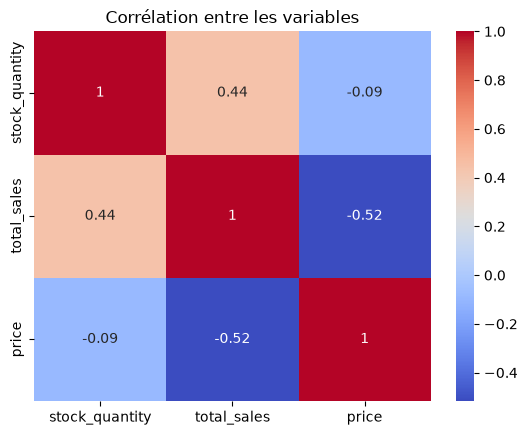

,stock_quantity,total_sales,price
stock_quantity,1.000000,0.438930,-0.089774
total_sales,0.438930,1.000000,-0.516258
price,-0.089774,-0.516258,1.000000


In [96]:
############################
# Analyse des corrélations #
############################

#Importation de Seaborn
import seaborn as sns
import matplotlib.pyplot as plt

df_erp_liaison_web[['stock_quantity', 'total_sales', 'price']].corr()   
#Création d'une heatmap de corrélation avec les variables stock, sales et price
corr = df_erp_liaison_web[['stock_quantity', 'total_sales', 'price']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Corrélation entre les variables')
plt.show()  
#On peut également créer un mask pour n'afficher qu'une demi heatmap
df_erp_liaison_web[['stock_quantity', 'total_sales', 'price']].corr()   

In [97]:
#.corr() — calcule la corrélation entre les colonnes. Un nombre entre -1 et 1 qui indique si deux variables évoluent ensemble (1 = toujours ensemble, -1 = toujours opposées, 0 = aucun lien).

#sns — c'est Seaborn, une librairie de visualisation. Il faudra l'importer avec import seaborn as sns.

#sns.heatmap() — crée une carte de chaleur qui affiche visuellement les corrélations avec des couleurs.

#plt — c'est matplotlib.pyplot, pour le titre et l'affichage. Il faudra aussi import matplotlib.pyplot as plt.

In [98]:
#Que peut-on conclure des corrélations 
# Les corrélations sont toutes faibles (proches de 0)
# Le prix a un léger impact négatif sur les ventes (-0.27)
# les articles avec plus de stock se vendent un peu plus, mais le lien n'est pas fort (0.29) mais correlation posiitif ici
#0.087 — quasi aucun lien entre le prix et la quantité en stock
# Aucune relation forte entre ces trois variables

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.6 - Mise à disposition de la nouvelle table sur un fichier Excel</h3>
</div>

In [99]:
#Mettre le dataset df_merge sur un fichier Excel
#Cette étape peut être utile pour partager le résultat du dataset obtenu avec les équipes.  
df_erp_liaison_web.to_excel("df_erp_liaison_web.xlsx", index=False)

PermissionError: [Errno 13] Permission denied: 'df_erp_liaison_web.xlsx'

In [ ]:
print("Nombre d'EAN final :", df_erp_liaison_web.shape[0])
# les 825 provienneent du fichiers erp , mais aussi lie a liaison apres la fusion avec le fichier web, donc le nombre d'EAN final est de 825.

Nombre d'EAN final : 825
